## <center> __University of Santo Tomas – Faculty of Engineering Electronics Engineering Department__ </center>
## <center> __ECE 2112: Advanced Computer Programming and Algorithms__ </center>
# <center> __EXPERIMENT 4: DATA WRANGLING AND DATA VISUALIZATION__ </center> 
#### Emmanuelle D.G. Miran| 2ECE-C
## **I.** Intended Learning Outcomes
1. Filter tabular data using several categorical and numerical conditions;
2. Construct focused DataFrames by selecting relevant features;
3. Summarize the relationship between categorical features and a numerical variable; and
4. Communicate a data comparison using clear and correctly labeled plots.

## **II.** Panda and Matplot Initialization | Average Setup

In [1]:
import pandas as pd
mp = pd.read_excel('board2.xlsx')
mp

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [2]:
import matplotlib.pyplot as plt

In [3]:
mp['Average'] = mp[['Math', 'Electronics', 'GEAS', 'Communication']].mean(axis=1)

## **III.** Programming Problems

>  ##  **A.** VISAYAS COMMUNICATION DATAFRAME

>Create a DataFrame named VisComm containing students whose Hometown is Visayas and whose Track is Communication. Retain only these columns, in the stated order: Name, Gender, Math, Electronics, Average<br><br>
>Display the resulting DataFrame and its number of rows. Both filtering conditions must be applied to
the source dataset before the columns are selected.

> ## Code & Outputs

In [4]:
VisComm = mp[(mp['Hometown'] == 'Visayas') & (mp['Track'] == 'Communication')][['Name', 'Gender', 'Math', 'Electronics', 'Average']]
VisComm

,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,54.75
11,S12,Male,89,67,76.00
17,S18,Male,81,40,63.50
21,S22,Female,64,39,62.50
27,S28,Male,85,53,67.75


In [5]:
print("Number of rows in VisComm:", len(VisComm))

Number of rows in VisComm: 5


>  ##  **B.** VISAYAS FEMALE DATAFRAME

>Create a second DataFrame named VisFemale containing students whose Hometown is Visayas and
whose Gender is Female. Retain only: Name, Track, GEAS, Electronics, Average<br><br>
>Display VisFemale. Then display only the rows of VisFemale whose Average is at least 60. Do not overwrite VisFemale when performing this second filter.

> ## Code & Outputs

In [6]:
VisFemale1 = mp[(mp['Hometown'] == 'Visayas') & (mp['Gender'] == 'Female')][['Name', 'Track', 'GEAS', 'Electronics', 'Average']]
VisFemale = VisFemale1[VisFemale1['Average'] >= 60]
VisFemale

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,75.50
20,S21,Microelectronics,68,51,68.50
21,S22,Communication,89,39,62.50
25,S26,Instrumentation,83,47,65.75


>  ##  **C.** Category-Average Visualization

>Examine how the recorded Average differs across the three categorical features Track, Gender, and Hometown.
>>**A.** For each feature, compute the mean of Average for every category using Pandas.<br>
>>**B.** Display the three summary tables.<br>
>>**C.** Create one figure containing three bar charts: mean Average by Track, by Gender, and by Hometown<br>
>>**D.** Below the figure, write three concise statements identifying the category with the highest sample mean for each feature<br>

>**Interpretation rule**: Describe the observed dataset only. A difference in group means does not, by itself, establish that a feature causes a higher board-exam score.

> ## Code & Outputs

In [7]:
track_mean = mp.groupby('Track')['Average'].mean().reset_index()
gender_mean = mp.groupby('Gender')['Average'].mean().reset_index()
hometown_mean = mp.groupby('Hometown')['Average'].mean().reset_index()

print('**Average Mean by Track**')
display(track_mean)
print('**Average Mean by Gender**')
display(gender_mean)
print('**Average Mean by Hometown**')
display(hometown_mean)

**Average Mean by Track**


,Track,Average
0,Communication,67.975
1,Instrumentation,65.225
2,Microelectronics,67.500


**Average Mean by Gender**


,Gender,Average
0,Female,66.616667
1,Male,67.183333


**Average Mean by Hometown**


,Hometown,Average
0,Luzon,68.083333
1,Mindanao,66.678571
2,Visayas,65.750000


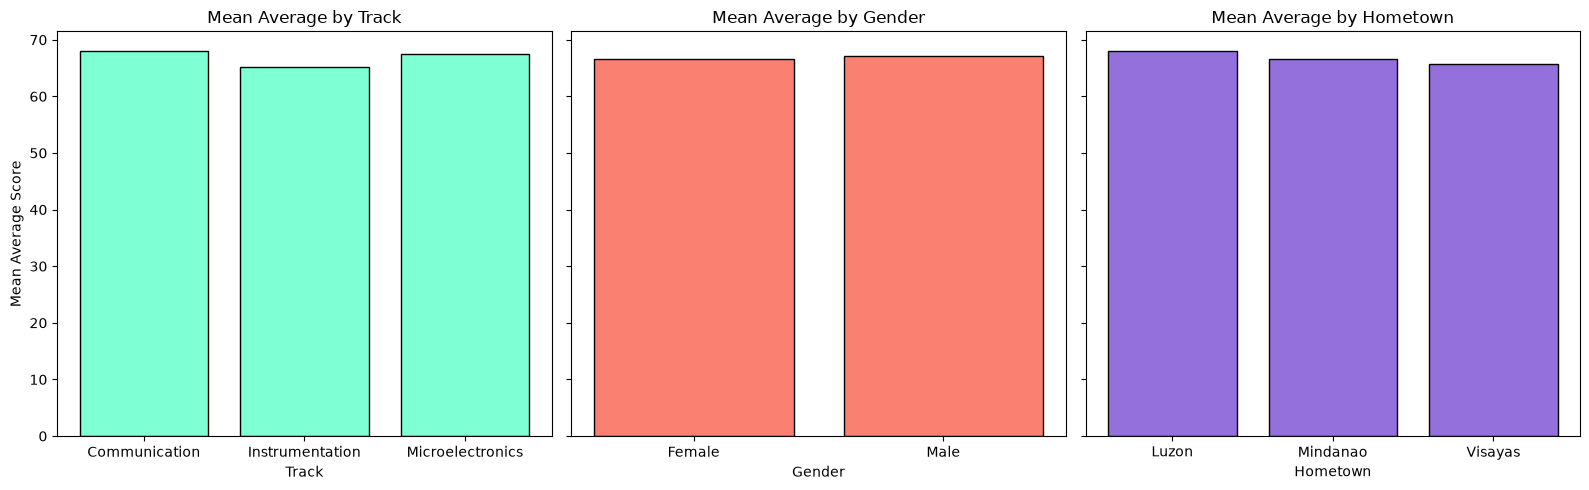

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

axes[0].bar(track_mean['Track'], track_mean['Average'], color='aquamarine', edgecolor='black')
axes[0].set_title('Mean Average by Track')
axes[0].set_xlabel('Track')
axes[0].set_ylabel('Mean Average Score')

axes[1].bar(gender_mean['Gender'], gender_mean['Average'], color='salmon', edgecolor='black')
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')

axes[2].bar(hometown_mean['Hometown'], hometown_mean['Average'], color='mediumpurple', edgecolor='black')
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')

plt.tight_layout()
plt.show()

In [9]:
track_mean.loc[track_mean["Average"].idxmax()];
gender_mean.loc[gender_mean["Average"].idxmax()];
hometown_mean.loc[hometown_mean["Average"].idxmax()];

In [10]:
print(f"1. Track: The {track_mean.loc[track_mean['Average'].idxmax(), 'Track']} track recorded the highest sample mean Average score ({track_mean['Average'].max()}).")

print(f"2. Gender: {gender_mean.loc[gender_mean['Average'].idxmax(), 'Gender']} students recorded the highest sample mean Average score ({gender_mean['Average'].max()}).")

print(f"3. Hometown: Students from {hometown_mean.loc[hometown_mean['Average'].idxmax(), 'Hometown']} recorded the highest sample mean Average score ({hometown_mean['Average'].max()}).")

1. Track: The Communication track recorded the highest sample mean Average score (67.975).
2. Gender: Male students recorded the highest sample mean Average score (67.18333333333334).
3. Hometown: Students from Luzon recorded the highest sample mean Average score (68.08333333333333).
